In [1]:
from pathlib import Path
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import spatialdata as sd
import spatialdata_plot  # registers .pl accessor

REPO_DIR = Path("/scratch/dkz4822/biohackathon2026/KIDS26-Team18/")  # repo root
SRC_DIR = REPO_DIR / "src"
RAW_DIR = Path("/scratch/dkz4822/biohackathon2026")   # where sdata.zarr actually lives

sys.path.insert(0, str(SRC_DIR))

from plot import SpatialCoord_plot, custom_barplot

In [2]:
from pathlib import Path
import sys

REPO_DIR = Path("/scratch/dkz4822/biohackathon2026/KIDS26-Team18/")  # repo root
SRC_DIR = REPO_DIR / "src"
RAW_DIR = Path("/scratch/dkz4822/biohackathon2026")   # where sdata.zarr actually lives

sys.path.insert(0, str(SRC_DIR))

from load_explore import setup_notebook_paths
from spatial_plot import plot_gene_seg_transcripts

In [3]:
SDATA_PATH = Path("/scratch/dkz4822/biohackathon2026/sdata_data6.zarr")
sdata = sd.read_zarr(SDATA_PATH)
adata = sdata["table"]

print("Tables:", list(sdata.tables.keys()))
print("Shapes:", list(sdata.shapes.keys()))
print("Points:", list(sdata.points.keys()))
print("Images:", list(sdata.images.keys()) or "(none)")
print(f"\nAnnData: {adata.n_obs:,} cells x {adata.n_vars:,} genes")
print(f"obs columns ({len(adata.obs.columns)}): {list(adata.obs.columns)[:12]} ...")
print(f"obsm keys: {list(adata.obsm.keys())}")
print(f"layers: {list(adata.layers.keys()) or '(none)'}")
print(f"Table region: {adata.uns['spatialdata_attrs']['region']}")

Tables: ['table']
Shapes: ['cell_boundaries']
Points: ['transcripts']
Images: (none)

AnnData: 71,138 cells x 6,537 genes
obs columns (134): ['RNA_Dermis_RNA_pipeline_Cell.Typing.InSituType.2_1_clusters', 'RNA_Dermis_RNA_pipeline_Cell.Typing.InSituType.2_1_posterior_probability', 'RNA_Dermis_RNA_pipeline_Cell.Typing.InSituType.1_1_clusters', 'RNA_Dermis_RNA_pipeline_Cell.Typing.InSituType.1_1_posterior_probability', 'RNA_Derma_Skin_RNA_sup_semisup_Cell.Typing.InSituType.2_1_clusters', 'RNA_Derma_Skin_RNA_sup_semisup_Cell.Typing.InSituType.2_1_posterior_probability', 'RNA_Derma_Skin_RNA_sup_semisup_Cell.Typing.InSituType.1_1_clusters', 'RNA_Derma_Skin_RNA_sup_semisup_Cell.Typing.InSituType.1_1_posterior_probability', 'fov', 'Area', 'AspectRatio', 'CenterX_local_px'] ...
obsm keys: ['spatial', 'global']
layers: (none)
Table region: cell_boundaries


In [4]:
# Sanity check: .X should hold integer raw RNA counts
x = adata.X
vals = x.data if hasattr(x, "data") else np.asarray(x).ravel()

assert vals.min() >= 0, f"Expected nonnegative counts, got min={vals.min()}"
assert np.allclose(vals, np.round(vals)), "Non-integer values in .X"

# exprMat includes Negative/SystemControl probes; compare RNA genes only to nCount_RNA
rna_mask = ~adata.var_names.str.match(r"^(Negative|SystemControl)")
row_sums = np.asarray(adata[:, rna_mask].X.sum(axis=1)).ravel()
ref = adata.obs["nCount_RNA"].to_numpy(dtype=float)
assert np.allclose(row_sums, ref, atol=5), "X row sums (RNA genes) must match obs['nCount_RNA']"

print(f"X holds integer counts (min={vals.min():.0f}, max={vals.max():.0f})")
print(f"Row-sum check vs nCount_RNA (RNA genes, atol=5): OK ({adata.n_obs:,} cells)")

X holds integer counts (min=1, max=699)
Row-sum check vs nCount_RNA (RNA genes, atol=5): OK (71,138 cells)


In [5]:
from sklearn.cluster import DBSCAN

coords = adata.obs[["CenterX_global_px", "CenterY_global_px"]].to_numpy()

# gaps between cores look like several thousand px; start with eps=2000
clustering = DBSCAN(eps=2000, min_samples=50).fit(coords)
adata.obs["tma_core"] = clustering.labels_.astype(str)

print(adata.obs["tma_core"].value_counts())
print("Number of cores found (excluding noise):", 
      len(set(clustering.labels_)) - (1 if -1 in clustering.labels_ else 0))

tma_core
16    6821
17    6148
2     5228
13    4881
7     4373
4     4315
11    3952
9     3915
1     3358
19    3334
0     2981
14    2766
15    2761
10    2728
6     2692
18    2613
12    2525
3     2086
8     1926
5     1735
Name: count, dtype: int64
Number of cores found (excluding noise): 20


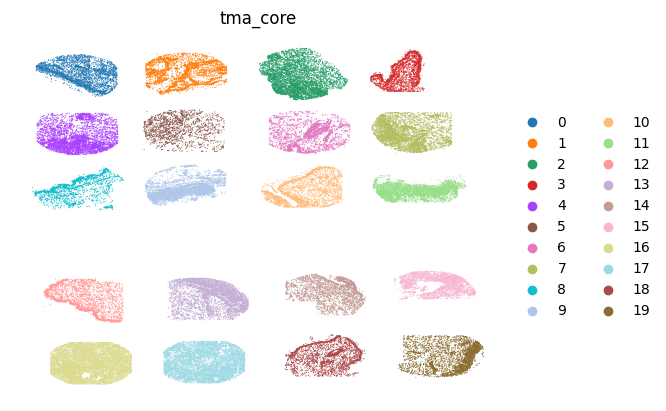

In [6]:
SpatialCoord_plot(
    adata,
    variable="tma_core",
    x_col="CenterX_global_px",
    y_col="CenterY_global_px",
    size=2,
)

In [7]:
one_core = adata[adata.obs["tma_core"] == "13"].copy()
print(one_core.shape)

(4881, 6537)


In [8]:
core_id = "13"  # whichever label corresponds to the core you want

adata_core = adata[adata.obs["tma_core"] == core_id].copy()
print(adata_core.shape)

(4881, 6537)


In [9]:
# Remove CosMx negative probes and system controls once, from the source object
control_mask = (
    adata_core.var_names.str.startswith("SystemControl")
    | adata_core.var_names.str.startswith("Negative")
    | adata_core.var_names.str.endswith("-circ")
    | (adata_core.var_names == "oChIEF")
    
)
print(f"Removing {control_mask.sum()} control/negative probes out of {adata_core.n_vars} genes")
adata_core = adata_core[:, ~control_mask].copy()

SCANPY_CFG = {
    "n_pcs": 30,
    "n_neighbors": 15,
    "leiden_resolution": 1.0,
    "seed": 42,
}

adata_core_sc = adata_core.copy()

sc.pp.normalize_total(adata_core_sc, target_sum=1e4)
sc.pp.log1p(adata_core_sc)
# No HVG subsetting — keeping all remaining (non-control) genes
sc.pp.scale(adata_core_sc, max_value=10)

n_comps = min(SCANPY_CFG["n_pcs"], adata_core_sc.n_obs - 1, adata_core_sc.n_vars - 1)
sc.tl.pca(adata_core_sc, n_comps=n_comps, random_state=SCANPY_CFG["seed"])
sc.pp.neighbors(adata_core_sc, n_neighbors=SCANPY_CFG["n_neighbors"])
sc.tl.leiden(
    adata_core_sc,
    resolution=SCANPY_CFG["leiden_resolution"],
    key_added="leiden",
    #flavor="igraph",
    #n_iterations=2,
    random_state=SCANPY_CFG["seed"],
)
sc.tl.umap(adata_core_sc, random_state=SCANPY_CFG["seed"])

adata_core.obs["leiden"] = adata_core_sc.obs["leiden"].astype(str)
adata_core.obsm["X_umap"] = adata_core_sc.obsm["X_umap"]

Removing 355 control/negative probes out of 6537 genes


/home/dkz4822/.conda/envs/biohackathon26/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_3830451/114185483.py:29: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


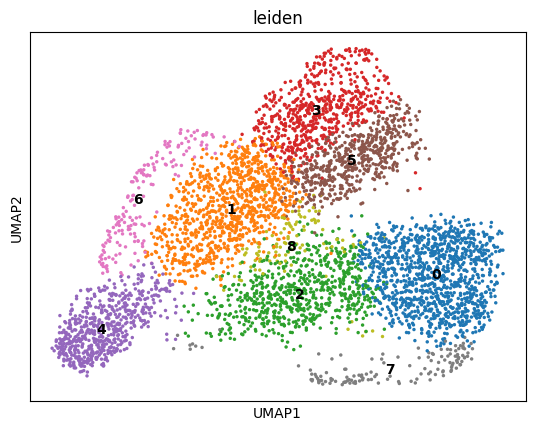

In [10]:
sc.pl.umap(
    adata_core,
    color=["leiden"],
    legend_loc="on data",
)

In [11]:
adata_core_sc = adata_core.copy()
# use all genes (no HVG subset)
sc.pp.normalize_total(adata_core_sc, target_sum=1e4)
sc.pp.log1p(adata_core_sc)
sc.tl.rank_genes_groups(adata_core_sc, groupby="leiden", method="wilcoxon", use_raw=False)
adata_core.uns["rank_genes_groups"] = adata_core_sc.uns["rank_genes_groups"]

,cluster,names,scores,logfoldchanges,pvals,pvals_adj
0,0,KRT5,33.785633,4.655204,3.206244e-250,1.982100e-246
1,0,DSC3,32.934563,3.680256,7.038129e-238,2.175486e-234
2,0,KRT14,32.872463,4.369411,5.440823e-237,1.121172e-233
3,0,KRT6A,31.723980,3.661587,7.257317e-221,1.121618e-217
4,0,S100A9,31.610085,4.226388,2.683591e-219,3.317992e-216
...,...,...,...,...,...,...
85,8,MYH9,3.228410,1.234877,1.244803e-03,4.050196e-01
86,8,HMGA1,2.985541,1.092975,2.830768e-03,8.333242e-01
87,8,ANGPTL4,2.900128,1.706957,3.730100e-03,9.223791e-01
88,8,CEBPB,2.878474,1.282981,3.996039e-03,9.501352e-01


/home/dkz4822/.conda/envs/biohackathon26/lib/python3.12/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 6182 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


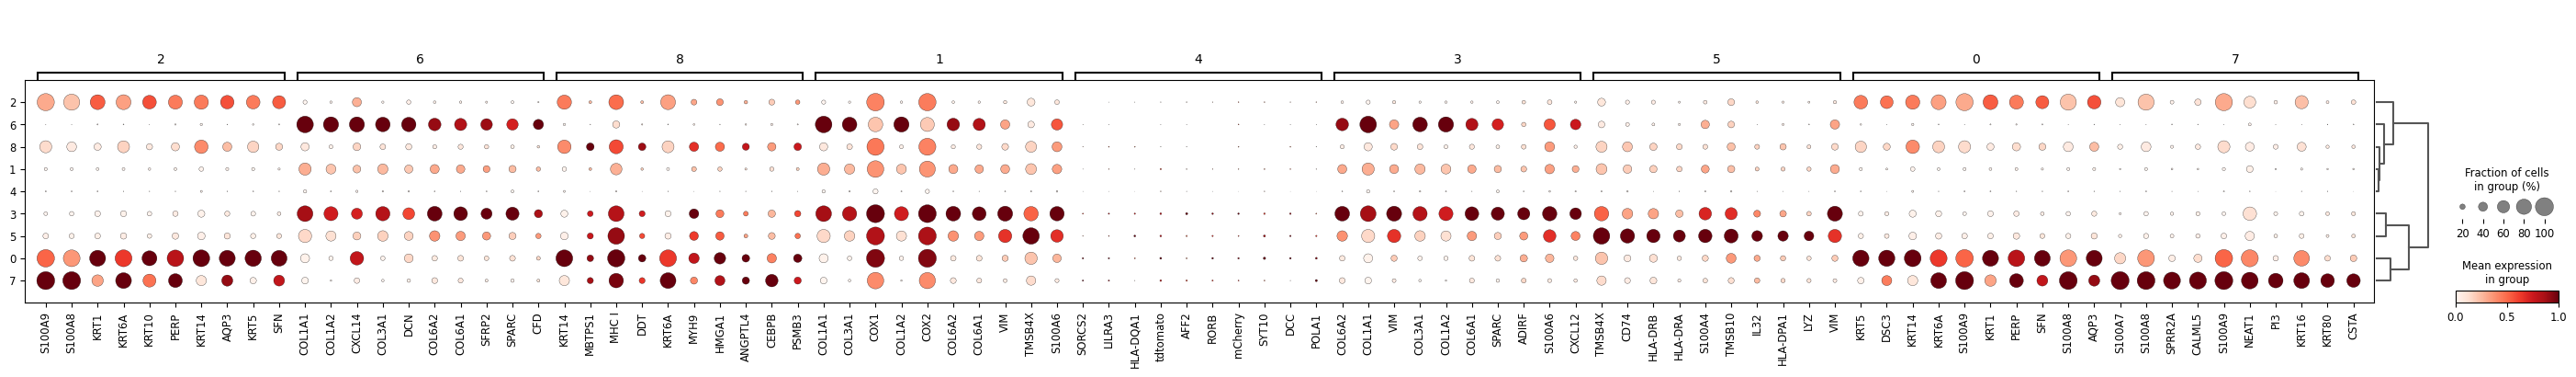

In [12]:
#top_n = SCANPY_CFG["rank_genes_top_n"]
top_n = 10
clusters = sorted(adata_core.obs["leiden"].unique(), key=lambda x: int(x))

marker_tables = []
for cluster in clusters:
    df = sc.get.rank_genes_groups_df(adata_core, group=cluster)
    df = df.head(top_n).copy()
    df.insert(0, "cluster", cluster)
    marker_tables.append(df)

markers_top20 = pd.concat(marker_tables, ignore_index=True)
display(markers_top20)

sc.tl.dendrogram(adata_core, groupby="leiden")

sc.pl.rank_genes_groups_dotplot(
    adata_core,
    n_genes=top_n,
    groupby="leiden",
    standard_scale="var",
    show=False,
)
plt.show()

In [14]:
marker_dict = (
    markers_top20
    .groupby("cluster", sort=False)["names"]
    .apply(list)
    .to_dict()
)

marker_dict

{'0': ['KRT5',
  'DSC3',
  'KRT14',
  'KRT6A',
  'S100A9',
  'KRT1',
  'PERP',
  'SFN',
  'S100A8',
  'AQP3'],
 '1': ['COL1A1',
  'COL3A1',
  'COX1',
  'COL1A2',
  'COX2',
  'COL6A2',
  'COL6A1',
  'VIM',
  'TMSB4X',
  'S100A6'],
 '2': ['S100A9',
  'S100A8',
  'KRT1',
  'KRT6A',
  'KRT10',
  'PERP',
  'KRT14',
  'AQP3',
  'KRT5',
  'SFN'],
 '3': ['COL6A2',
  'COL1A1',
  'VIM',
  'COL3A1',
  'COL1A2',
  'COL6A1',
  'SPARC',
  'ADIRF',
  'S100A6',
  'CXCL12'],
 '4': ['SORCS2',
  'LILRA3',
  'HLA-DQA1',
  'tdtomato',
  'AFF2',
  'RORB',
  'mCherry',
  'SYT10',
  'DCC',
  'POLA1'],
 '5': ['TMSB4X',
  'CD74',
  'HLA-DRB',
  'HLA-DRA',
  'S100A4',
  'TMSB10',
  'IL32',
  'HLA-DPA1',
  'LYZ',
  'VIM'],
 '6': ['COL1A1',
  'COL1A2',
  'CXCL14',
  'COL3A1',
  'DCN',
  'COL6A2',
  'COL6A1',
  'SFRP2',
  'SPARC',
  'CFD'],
 '7': ['S100A7',
  'S100A8',
  'SPRR2A',
  'CALML5',
  'S100A9',
  'NEAT1',
  'PI3',
  'KRT16',
  'KRT80',
  'CSTA'],
 '8': ['KRT14',
  'MBTPS1',
  'MHC I',
  'DDT',
  'KRT6A',


In [15]:
# Update this dict after reviewing the marker tables above.
# Keys are Leiden cluster IDs (strings). Unmapped clusters become "Unassigned".
CLUSTER_ANNOTATIONS = {
    "0": "Keratinocyte",
    "1": "Fibroblast",
    "2": "Keratinocyte",
    "3": "Fibroblast",
    "4": "Unknown",
    "5": "Macrophage",
    "6": "Fibroblast",
    "7": "Inflamed keratinocyte",
    "8": "Keratinocyte",
}

adata_core.obs["cell_type_scanpy"] = (
    adata_core.obs["leiden"]
    .astype(str)
    .map(CLUSTER_ANNOTATIONS)
    .fillna("Unassigned")
)

adata_core.obs["cell_type_scanpy"] = adata_core.obs["cell_type_scanpy"].astype("category")

display(
    adata_core.obs["cell_type_scanpy"].value_counts(dropna=False)
)

cell_type_scanpy
Keratinocyte             1897
Fibroblast               1698
Unknown                   602
Macrophage                549
Inflamed keratinocyte     135
Name: count, dtype: int64

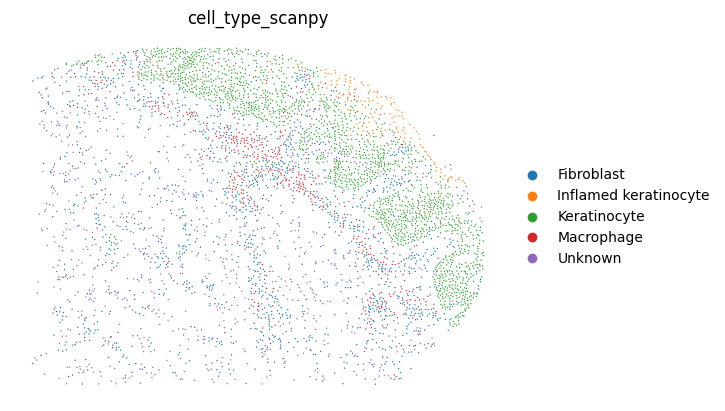

In [16]:
ax = SpatialCoord_plot(
    adata_core,
    variable="cell_type_scanpy",
    x_col="CenterX_global_px",
    y_col="CenterY_global_px",
    size=4,
    show=False,
)
ax.figure.savefig("SpatialCoord_plot_data6_TMA13.png", dpi=300, bbox_inches="tight")

# 3. Approach ii — rule-based keratinocyte /  fibroblast typing

# Part A: deciding on the best candidate genes: prefarably use the high tier

In [18]:
KERA_CANDIDATES = [
    "KRT5", "KRT14", "KRT1", "KRT10", "PERP", "SFN", "DSC3",
    "KRT6A", "KRT16", "KRT17", "DSG3", "CDH1",
]
FIBRO_CANDIDATES = [
    "COL1A1", "COL1A2", "COL3A1", "DCN", "LUM", "PDGFRA",
    "PDGFRB", "SPARC", "CFD", "SFRP2", "VIM", "CXCL12",
]
MACRO_CANDIDATES = [
    "CD68", "CD163", "CD14", "ITGAM", "MRC1", "LYZ",
    "C1QA", "C1QB", "C1QC", "CSF1R", "AIF1", "FCGR3A",
]
INFL_KERA_CANDIDATES = [
    "S100A7", "S100A8", "S100A9", "DEFB4A", "LCN2",
    "KRT6A", "KRT16", "KRT17", "SPRR2A", "PI3",
    "CXCL8", "IL36G",
]

candidate_sets = {
    "KERA": KERA_CANDIDATES,
    "FIBRO": FIBRO_CANDIDATES,
    "MACRO": MACRO_CANDIDATES,
    "INFL_KERA": INFL_KERA_CANDIDATES,
}

def detection_rate(adata_core, genes):
    """Fraction of cells with raw count > 0 for each gene in adata."""
    present = [g for g in genes if g in adata_core.var_names]
    rates = {}
    for gene in present:
        x = adata_core[:, gene].X
        if hasattr(x, "toarray"):
            x = x.toarray().ravel()
        else:
            x = np.asarray(x).ravel()
        rates[gene] = float((x > 0).mean())
    return pd.Series(rates).sort_values(ascending=False)
    
detection_rates = {}
for label, genes in candidate_sets.items():
    rates = detection_rate(adata_core, genes)
    detection_rates[label] = rates
    n_present = len(rates)
    print(f"{label}: {n_present} of {len(genes)} candidates present in panel")
    display(rates)

KERA: 12 of 12 candidates present in panel


KRT14    0.445196
KRT6A    0.425937
PERP     0.401762
KRT1     0.392952
KRT5     0.377382
KRT16    0.363040
DSC3     0.351158
SFN      0.350338
KRT10    0.348494
KRT17    0.302602
CDH1     0.221061
DSG3     0.131326
dtype: float64

FIBRO: 12 of 12 candidates present in panel


COL1A1    0.459332
VIM       0.341528
DCN       0.327392
COL3A1    0.317148
COL1A2    0.303831
SPARC     0.266134
CXCL12    0.233559
SFRP2     0.228027
LUM       0.183979
PDGFRB    0.155501
CFD       0.148740
PDGFRA    0.107355
dtype: float64

MACRO: 12 of 12 candidates present in panel


LYZ       0.145667
CD14      0.124770
FCGR3A    0.119033
C1QC      0.113296
C1QA      0.106740
CD68      0.104487
MRC1      0.090760
AIF1      0.064126
CD163     0.060234
CSF1R     0.060029
C1QB      0.059004
ITGAM     0.057160
dtype: float64

INFL_KERA: 11 of 12 candidates present in panel


S100A9    0.449088
KRT6A     0.425937
S100A8    0.423069
KRT16     0.363040
KRT17     0.302602
S100A7    0.234173
SPRR2A    0.140340
PI3       0.122516
IL36G     0.118623
LCN2      0.117394
CXCL8     0.086458
dtype: float64

In [19]:
def split_by_tier(detection_rates, n_per_tier=5):
    """Split a ranked detection-rate Series into low and high tiers."""
    ranked = detection_rates.sort_values(ascending=False)
    high_tier = ranked.head(n_per_tier)
    low_tier = ranked.tail(n_per_tier)
    return low_tier, high_tier

# widen your candidate pools first if needed (see previous message) so each
# tier has enough genes to draw k up to 5 from
tiers = {}
for label in candidate_sets:
    rates = detection_rates[label]
    low, high = split_by_tier(rates, n_per_tier=5)
    tiers[label] = {"low": low, "high": high}
    print(f"\n{label} — LOW tier:\n{low}")
    print(f"{label} — HIGH tier:\n{high}")


KERA — LOW tier:
SFN      0.350338
KRT10    0.348494
KRT17    0.302602
CDH1     0.221061
DSG3     0.131326
dtype: float64
KERA — HIGH tier:
KRT14    0.445196
KRT6A    0.425937
PERP     0.401762
KRT1     0.392952
KRT5     0.377382
dtype: float64

FIBRO — LOW tier:
SFRP2     0.228027
LUM       0.183979
PDGFRB    0.155501
CFD       0.148740
PDGFRA    0.107355
dtype: float64
FIBRO — HIGH tier:
COL1A1    0.459332
VIM       0.341528
DCN       0.327392
COL3A1    0.317148
COL1A2    0.303831
dtype: float64

MACRO — LOW tier:
AIF1     0.064126
CD163    0.060234
CSF1R    0.060029
C1QB     0.059004
ITGAM    0.057160
dtype: float64
MACRO — HIGH tier:
LYZ       0.145667
CD14      0.124770
FCGR3A    0.119033
C1QC      0.113296
C1QA      0.106740
dtype: float64

INFL_KERA — LOW tier:
SPRR2A    0.140340
PI3       0.122516
IL36G     0.118623
LCN2      0.117394
CXCL8     0.086458
dtype: float64
INFL_KERA — HIGH tier:
S100A9    0.449088
KRT6A     0.425937
S100A8    0.423069
KRT16     0.363040
KRT17     0


HIGH-tier, top 2 markers:
  KERA: ['KRT14', 'KRT6A']
  FIBRO: ['COL1A1', 'VIM']
  MACRO: ['LYZ', 'CD14']
  INFL_KERA: ['S100A9', 'KRT6A']

HIGH-tier, top 3 markers:
  KERA: ['KRT14', 'KRT6A', 'PERP']
  FIBRO: ['COL1A1', 'VIM', 'DCN']
  MACRO: ['LYZ', 'CD14', 'FCGR3A']
  INFL_KERA: ['S100A9', 'KRT6A', 'S100A8']

HIGH-tier, top 4 markers:
  KERA: ['KRT14', 'KRT6A', 'PERP', 'KRT1']
  FIBRO: ['COL1A1', 'VIM', 'DCN', 'COL3A1']
  MACRO: ['LYZ', 'CD14', 'FCGR3A', 'C1QC']
  INFL_KERA: ['S100A9', 'KRT6A', 'S100A8', 'KRT16']

LOW-tier, top 2 markers:
  KERA: ['CDH1', 'DSG3']
  FIBRO: ['CFD', 'PDGFRA']
  MACRO: ['C1QB', 'ITGAM']
  INFL_KERA: ['LCN2', 'CXCL8']

LOW-tier, top 3 markers:
  KERA: ['KRT17', 'CDH1', 'DSG3']
  FIBRO: ['PDGFRB', 'CFD', 'PDGFRA']
  MACRO: ['CSF1R', 'C1QB', 'ITGAM']
  INFL_KERA: ['IL36G', 'LCN2', 'CXCL8']

LOW-tier, top 4 markers:
  KERA: ['KRT10', 'KRT17', 'CDH1', 'DSG3']
  FIBRO: ['LUM', 'PDGFRB', 'CFD', 'PDGFRA']
  MACRO: ['CD163', 'CSF1R', 'C1QB', 'ITGAM']
  INFL_KERA

cell_type_rule_hightier_2
Unassigned               2059
Inflamed keratinocyte    1521
Fibroblast                872
Ambiguous                 296
Keratinocyte               94
Macrophage                 39
Name: count, dtype: int64

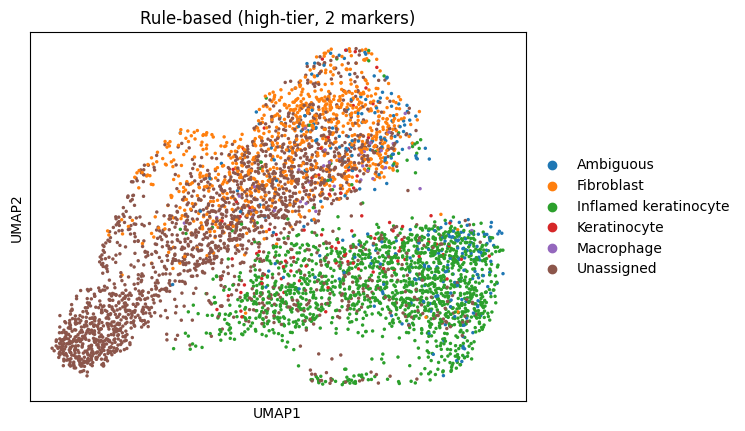

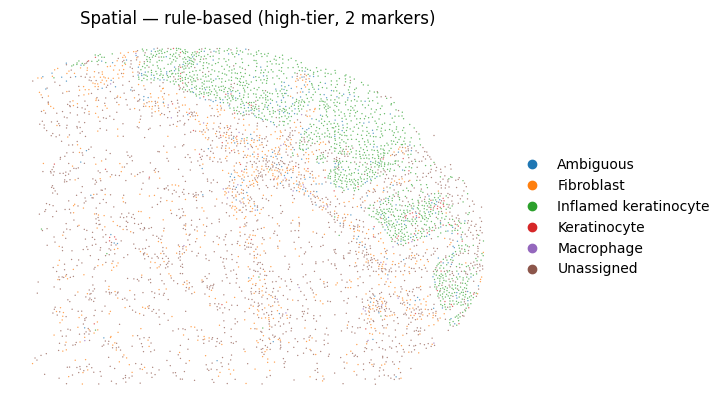

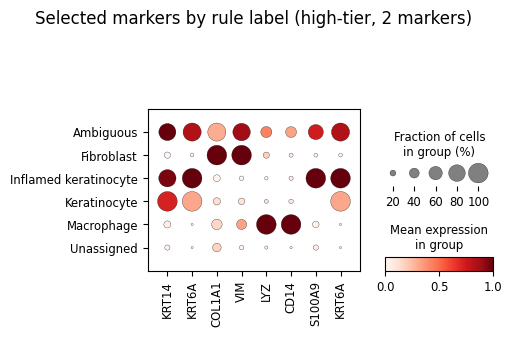


Comparison for sample (high-tier, 2 markers):

=== Counts ===


,cell_type_scanpy,cell_type_rule_hightier_2
Ambiguous,NaN,296.0
Fibroblast,1698.0,872.0
Inflamed keratinocyte,135.0,1521.0
Keratinocyte,1897.0,94.0
Macrophage,549.0,39.0
Unassigned,NaN,2059.0
Unknown,602.0,NaN



=== Crosstab (scanpy rows × rule cols) ===


cell_type_rule_hightier_2,Ambiguous,Fibroblast,Inflamed keratinocyte,Keratinocyte,Macrophage,Unassigned,All
cell_type_scanpy,,,,,,,
Fibroblast,60,646,26,19,11,936,1698
Inflamed keratinocyte,8,0,104,0,0,23,135
Keratinocyte,165,17,1370,63,3,279,1897
Macrophage,62,209,20,12,25,221,549
Unknown,1,0,1,0,0,600,602
All,296,872,1521,94,39,2059,4881



=== Row-normalized crosstab ===


cell_type_rule_hightier_2,Ambiguous,Fibroblast,Inflamed keratinocyte,Keratinocyte,Macrophage,Unassigned
cell_type_scanpy,,,,,,
Fibroblast,0.035,0.380,0.015,0.011,0.006,0.551
Inflamed keratinocyte,0.059,0.000,0.770,0.000,0.000,0.170
Keratinocyte,0.087,0.009,0.722,0.033,0.002,0.147
Macrophage,0.113,0.381,0.036,0.022,0.046,0.403
Unknown,0.002,0.000,0.002,0.000,0.000,0.997


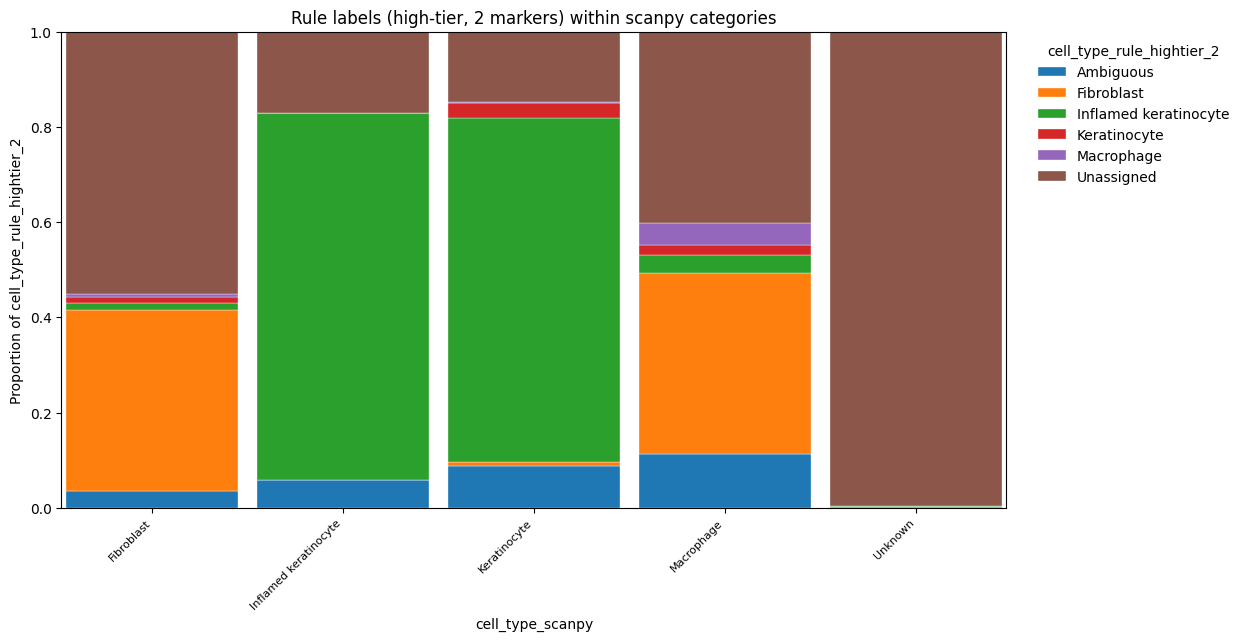


ROUND: HIGH-tier, 3 markers each
Rule-based labels (high-tier, 3 markers):


cell_type_rule_hightier_3
Unassigned               2634
Inflamed keratinocyte    1482
Fibroblast                533
Keratinocyte              135
Ambiguous                  87
Macrophage                 10
Name: count, dtype: int64

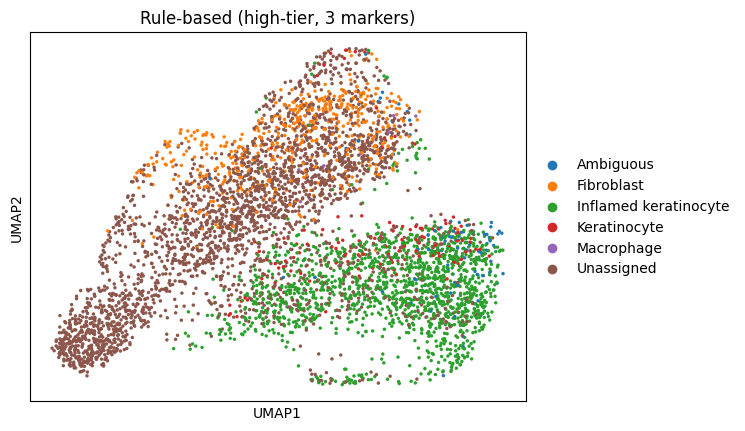

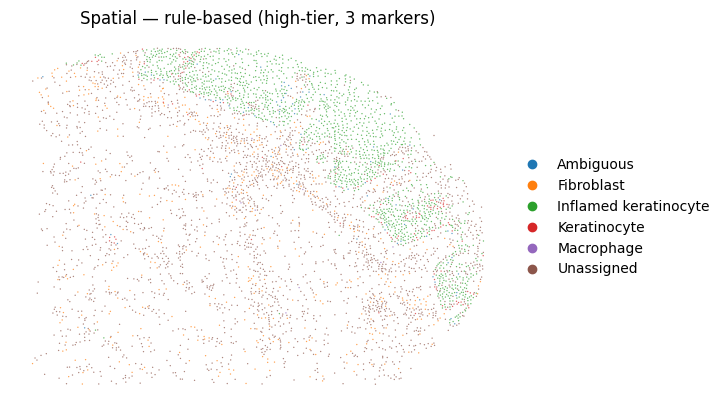

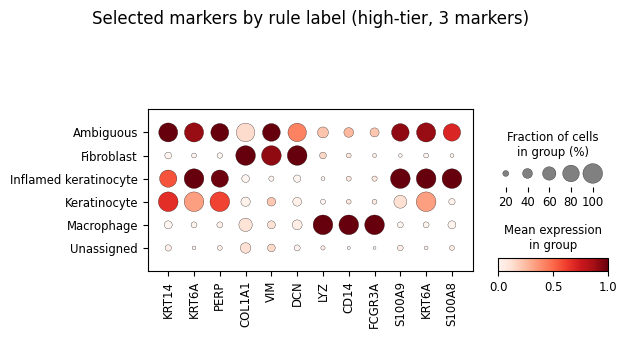


Comparison for sample (high-tier, 3 markers):

=== Counts ===


,cell_type_scanpy,cell_type_rule_hightier_3
Ambiguous,NaN,87.0
Fibroblast,1698.0,533.0
Inflamed keratinocyte,135.0,1482.0
Keratinocyte,1897.0,135.0
Macrophage,549.0,10.0
Unassigned,NaN,2634.0
Unknown,602.0,NaN



=== Crosstab (scanpy rows × rule cols) ===


cell_type_rule_hightier_3,Ambiguous,Fibroblast,Inflamed keratinocyte,Keratinocyte,Macrophage,Unassigned,All
cell_type_scanpy,,,,,,,
Fibroblast,6,418,20,12,1,1241,1698
Inflamed keratinocyte,2,0,110,0,0,23,135
Keratinocyte,70,7,1330,116,1,373,1897
Macrophage,9,108,22,7,8,395,549
Unknown,0,0,0,0,0,602,602
All,87,533,1482,135,10,2634,4881



=== Row-normalized crosstab ===


cell_type_rule_hightier_3,Ambiguous,Fibroblast,Inflamed keratinocyte,Keratinocyte,Macrophage,Unassigned
cell_type_scanpy,,,,,,
Fibroblast,0.004,0.246,0.012,0.007,0.001,0.731
Inflamed keratinocyte,0.015,0.000,0.815,0.000,0.000,0.170
Keratinocyte,0.037,0.004,0.701,0.061,0.001,0.197
Macrophage,0.016,0.197,0.040,0.013,0.015,0.719
Unknown,0.000,0.000,0.000,0.000,0.000,1.000


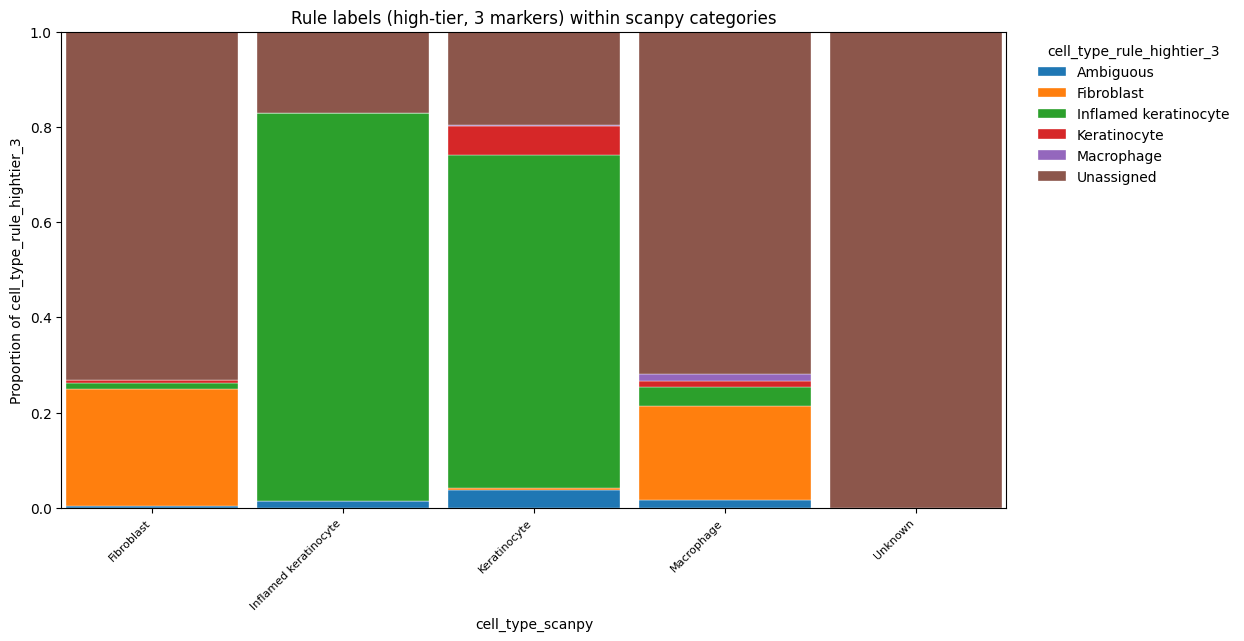


ROUND: HIGH-tier, 4 markers each
Rule-based labels (high-tier, 4 markers):


cell_type_rule_hightier_4
Unassigned               2906
Inflamed keratinocyte    1280
Fibroblast                480
Keratinocyte              192
Ambiguous                  17
Macrophage                  6
Name: count, dtype: int64

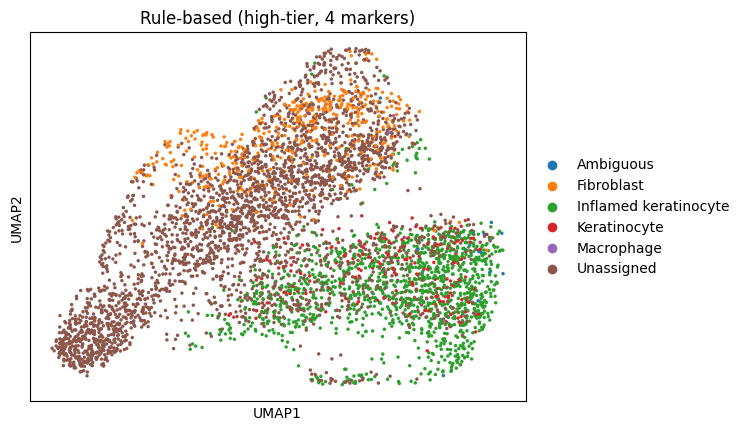

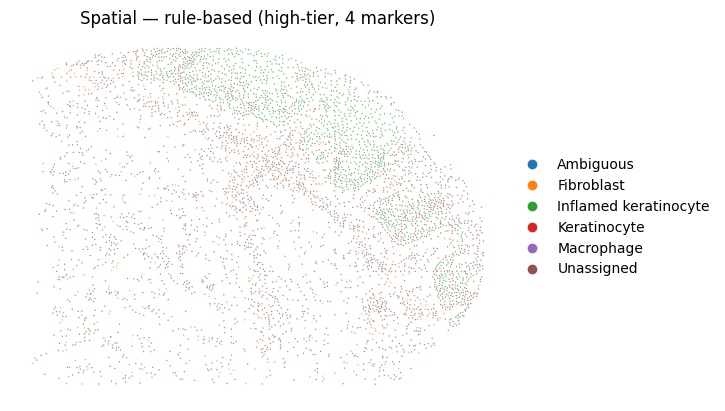

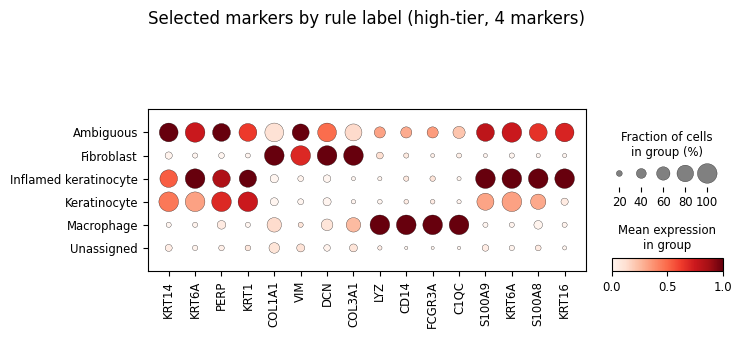


Comparison for sample (high-tier, 4 markers):

=== Counts ===


,cell_type_scanpy,cell_type_rule_hightier_4
Ambiguous,NaN,17.0
Fibroblast,1698.0,480.0
Inflamed keratinocyte,135.0,1280.0
Keratinocyte,1897.0,192.0
Macrophage,549.0,6.0
Unassigned,NaN,2906.0
Unknown,602.0,NaN



=== Crosstab (scanpy rows × rule cols) ===


cell_type_rule_hightier_4,Ambiguous,Fibroblast,Inflamed keratinocyte,Keratinocyte,Macrophage,Unassigned,All
cell_type_scanpy,,,,,,,
Fibroblast,1,385,10,2,1,1299,1698
Inflamed keratinocyte,1,0,104,0,0,30,135
Keratinocyte,14,8,1142,189,0,544,1897
Macrophage,1,87,24,1,5,431,549
Unknown,0,0,0,0,0,602,602
All,17,480,1280,192,6,2906,4881



=== Row-normalized crosstab ===


cell_type_rule_hightier_4,Ambiguous,Fibroblast,Inflamed keratinocyte,Keratinocyte,Macrophage,Unassigned
cell_type_scanpy,,,,,,
Fibroblast,0.001,0.227,0.006,0.001,0.001,0.765
Inflamed keratinocyte,0.007,0.000,0.770,0.000,0.000,0.222
Keratinocyte,0.007,0.004,0.602,0.100,0.000,0.287
Macrophage,0.002,0.158,0.044,0.002,0.009,0.785
Unknown,0.000,0.000,0.000,0.000,0.000,1.000


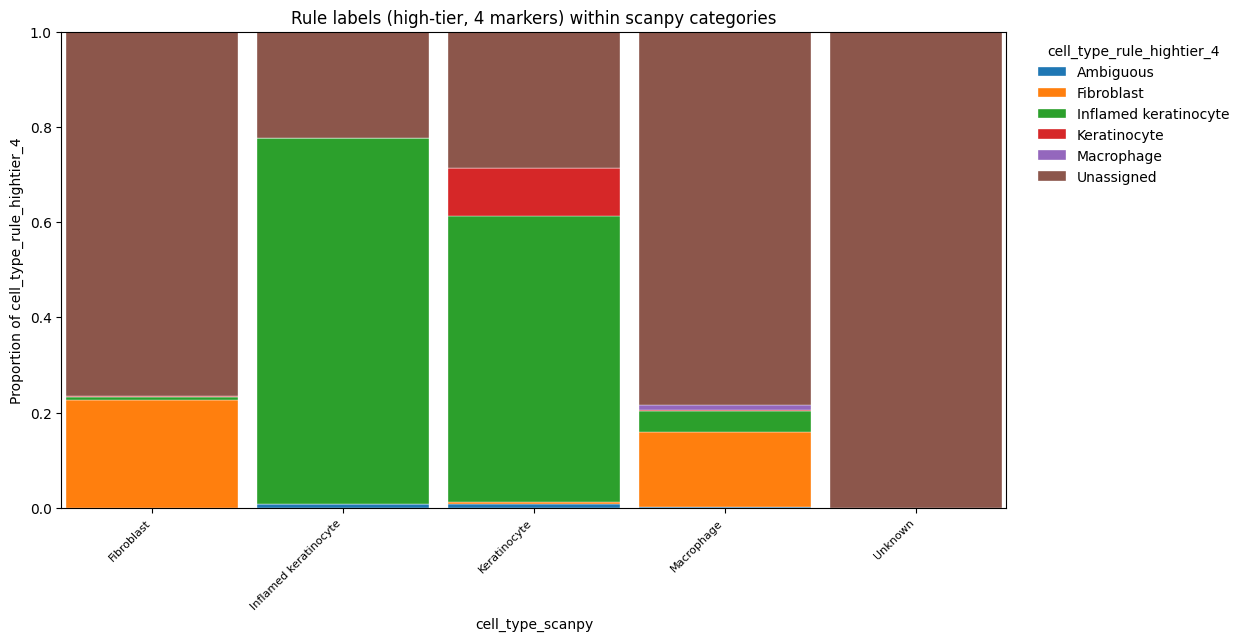


ROUND: LOW-tier, 2 markers each
Rule-based labels (low-tier, 2 markers):


cell_type_rule_lowtier_2
Unassigned               4406
Keratinocyte              248
Fibroblast                117
Inflamed keratinocyte      77
Ambiguous                  18
Macrophage                 15
Name: count, dtype: int64

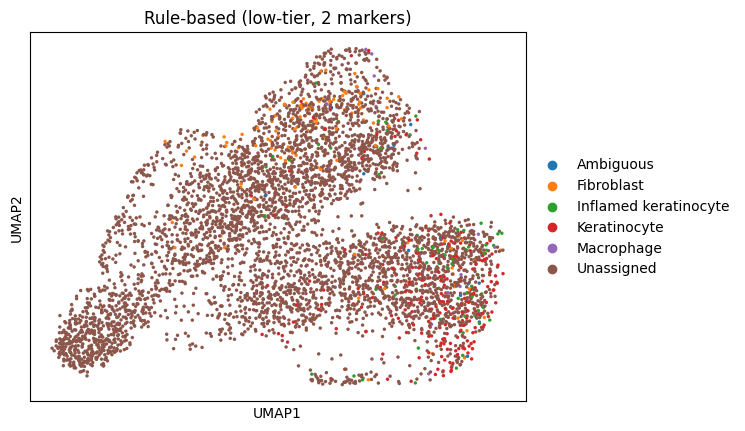

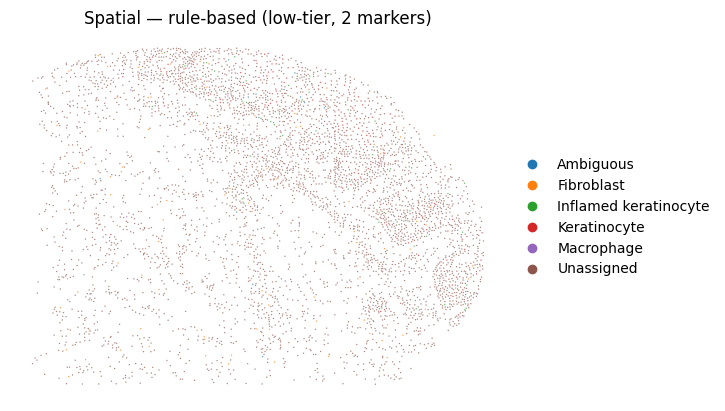

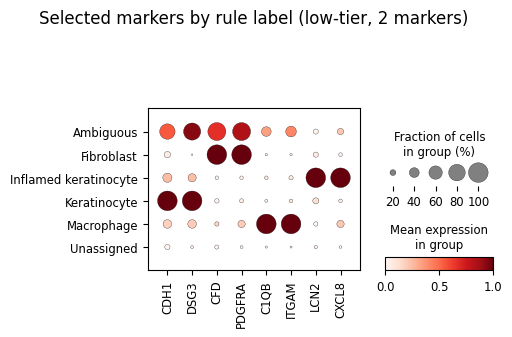


Comparison for sample (low-tier, 2 markers):

=== Counts ===


,cell_type_scanpy,cell_type_rule_lowtier_2
Ambiguous,NaN,18.0
Fibroblast,1698.0,117.0
Inflamed keratinocyte,135.0,77.0
Keratinocyte,1897.0,248.0
Macrophage,549.0,15.0
Unassigned,NaN,4406.0
Unknown,602.0,NaN



=== Crosstab (scanpy rows × rule cols) ===


cell_type_rule_lowtier_2,Ambiguous,Fibroblast,Inflamed keratinocyte,Keratinocyte,Macrophage,Unassigned,All
cell_type_scanpy,,,,,,,
Fibroblast,3,84,8,10,5,1588,1698
Inflamed keratinocyte,1,3,7,30,1,93,135
Keratinocyte,10,20,50,197,6,1614,1897
Macrophage,4,10,12,11,3,509,549
Unknown,0,0,0,0,0,602,602
All,18,117,77,248,15,4406,4881



=== Row-normalized crosstab ===


cell_type_rule_lowtier_2,Ambiguous,Fibroblast,Inflamed keratinocyte,Keratinocyte,Macrophage,Unassigned
cell_type_scanpy,,,,,,
Fibroblast,0.002,0.049,0.005,0.006,0.003,0.935
Inflamed keratinocyte,0.007,0.022,0.052,0.222,0.007,0.689
Keratinocyte,0.005,0.011,0.026,0.104,0.003,0.851
Macrophage,0.007,0.018,0.022,0.020,0.005,0.927
Unknown,0.000,0.000,0.000,0.000,0.000,1.000


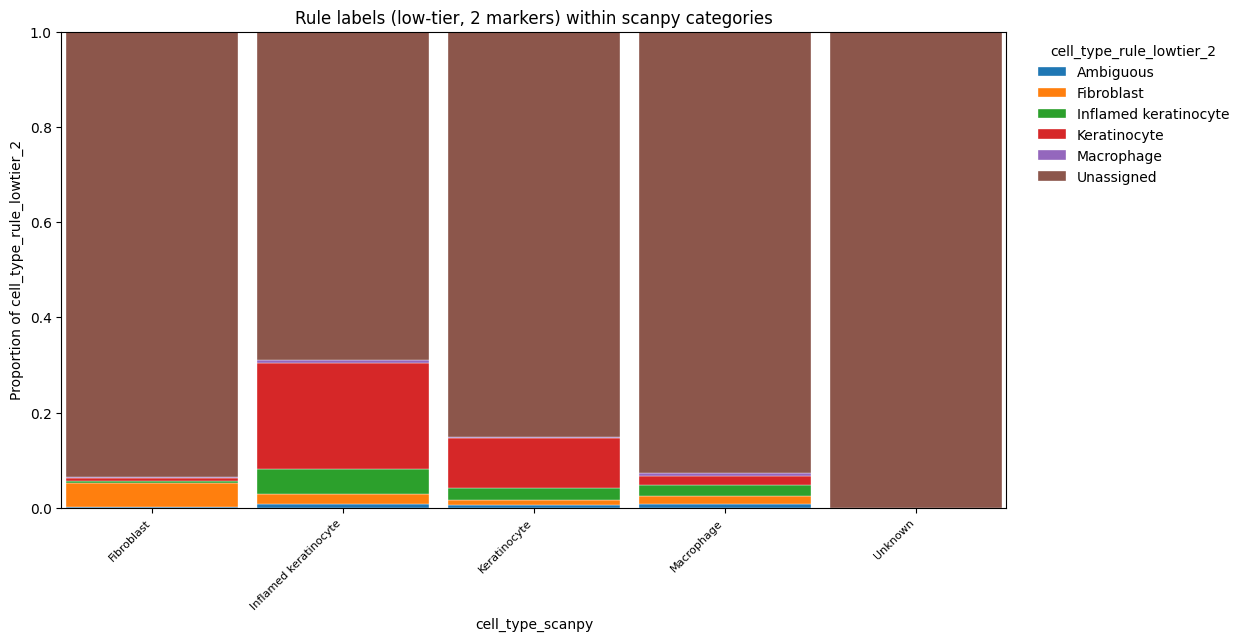


ROUND: LOW-tier, 3 markers each
Rule-based labels (low-tier, 3 markers):


cell_type_rule_lowtier_3
Unassigned               4604
Keratinocyte              191
Fibroblast                 54
Inflamed keratinocyte      25
Macrophage                  4
Ambiguous                   3
Name: count, dtype: int64

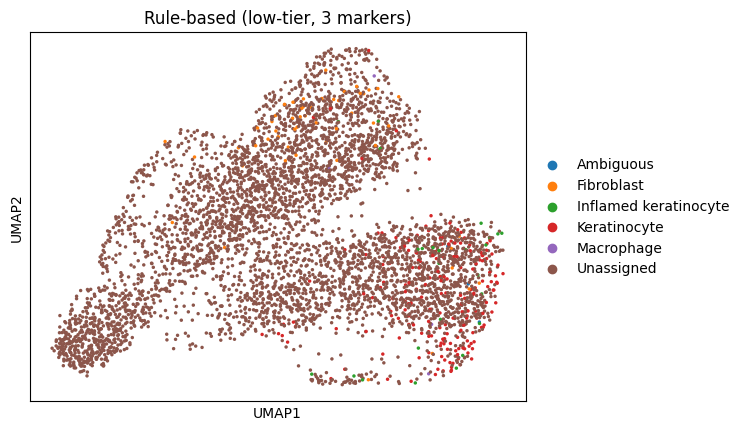

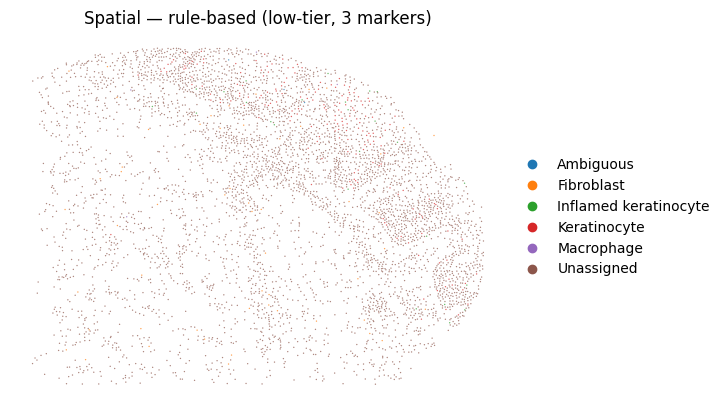

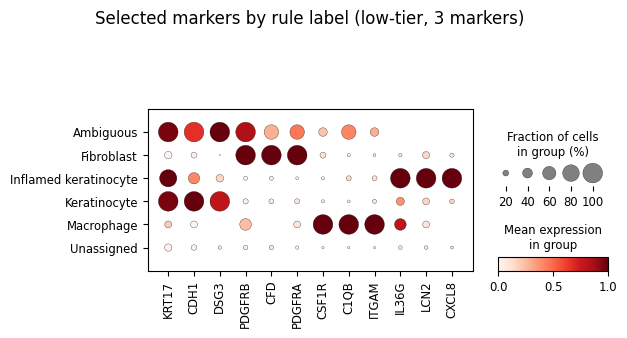


Comparison for sample (low-tier, 3 markers):

=== Counts ===


,cell_type_scanpy,cell_type_rule_lowtier_3
Ambiguous,NaN,3.0
Fibroblast,1698.0,54.0
Inflamed keratinocyte,135.0,25.0
Keratinocyte,1897.0,191.0
Macrophage,549.0,4.0
Unassigned,NaN,4604.0
Unknown,602.0,NaN



=== Crosstab (scanpy rows × rule cols) ===


cell_type_rule_lowtier_3,Ambiguous,Fibroblast,Inflamed keratinocyte,Keratinocyte,Macrophage,Unassigned,All
cell_type_scanpy,,,,,,,
Fibroblast,0,43,1,3,1,1650,1698
Inflamed keratinocyte,0,2,7,29,1,96,135
Keratinocyte,3,5,15,156,1,1717,1897
Macrophage,0,4,2,3,1,539,549
Unknown,0,0,0,0,0,602,602
All,3,54,25,191,4,4604,4881



=== Row-normalized crosstab ===


cell_type_rule_lowtier_3,Ambiguous,Fibroblast,Inflamed keratinocyte,Keratinocyte,Macrophage,Unassigned
cell_type_scanpy,,,,,,
Fibroblast,0.000,0.025,0.001,0.002,0.001,0.972
Inflamed keratinocyte,0.000,0.015,0.052,0.215,0.007,0.711
Keratinocyte,0.002,0.003,0.008,0.082,0.001,0.905
Macrophage,0.000,0.007,0.004,0.005,0.002,0.982
Unknown,0.000,0.000,0.000,0.000,0.000,1.000


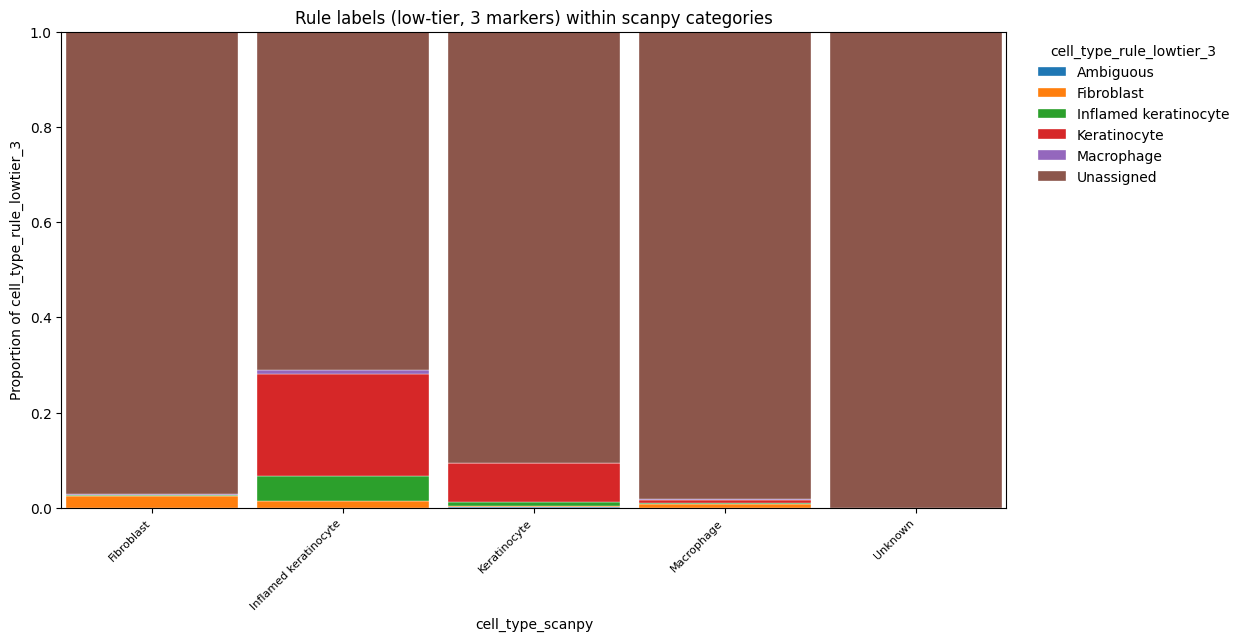


ROUND: LOW-tier, 4 markers each
Rule-based labels (low-tier, 4 markers):


cell_type_rule_lowtier_4
Unassigned               4692
Keratinocyte              154
Fibroblast                 22
Inflamed keratinocyte      11
Ambiguous                   1
Macrophage                  1
Name: count, dtype: int64

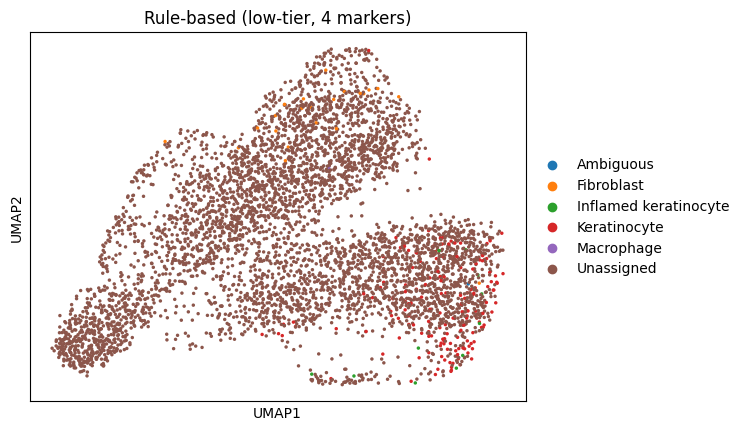

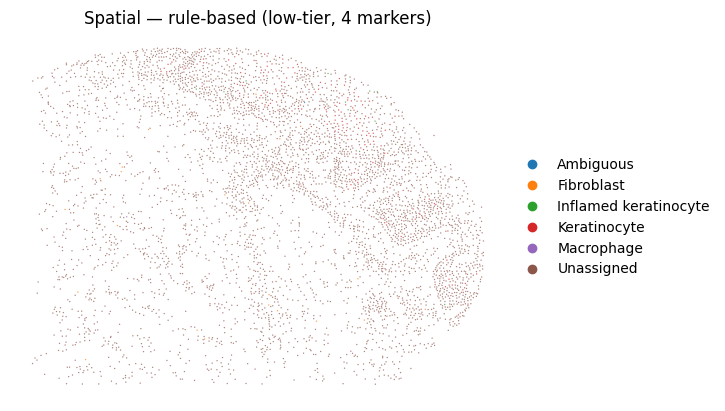

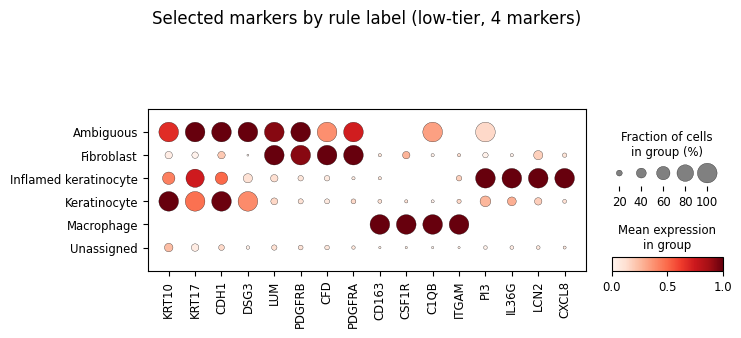


Comparison for sample (low-tier, 4 markers):

=== Counts ===


,cell_type_scanpy,cell_type_rule_lowtier_4
Ambiguous,NaN,1.0
Fibroblast,1698.0,22.0
Inflamed keratinocyte,135.0,11.0
Keratinocyte,1897.0,154.0
Macrophage,549.0,1.0
Unassigned,NaN,4692.0
Unknown,602.0,NaN



=== Crosstab (scanpy rows × rule cols) ===


cell_type_rule_lowtier_4,Ambiguous,Fibroblast,Inflamed keratinocyte,Keratinocyte,Macrophage,Unassigned,All
cell_type_scanpy,,,,,,,
Fibroblast,0,21,0,1,0,1676,1698
Inflamed keratinocyte,0,0,6,26,0,103,135
Keratinocyte,1,1,5,126,0,1764,1897
Macrophage,0,0,0,1,1,547,549
Unknown,0,0,0,0,0,602,602
All,1,22,11,154,1,4692,4881



=== Row-normalized crosstab ===


cell_type_rule_lowtier_4,Ambiguous,Fibroblast,Inflamed keratinocyte,Keratinocyte,Macrophage,Unassigned
cell_type_scanpy,,,,,,
Fibroblast,0.000,0.012,0.000,0.001,0.000,0.987
Inflamed keratinocyte,0.000,0.000,0.044,0.193,0.000,0.763
Keratinocyte,0.001,0.001,0.003,0.066,0.000,0.930
Macrophage,0.000,0.000,0.000,0.002,0.002,0.996
Unknown,0.000,0.000,0.000,0.000,0.000,1.000


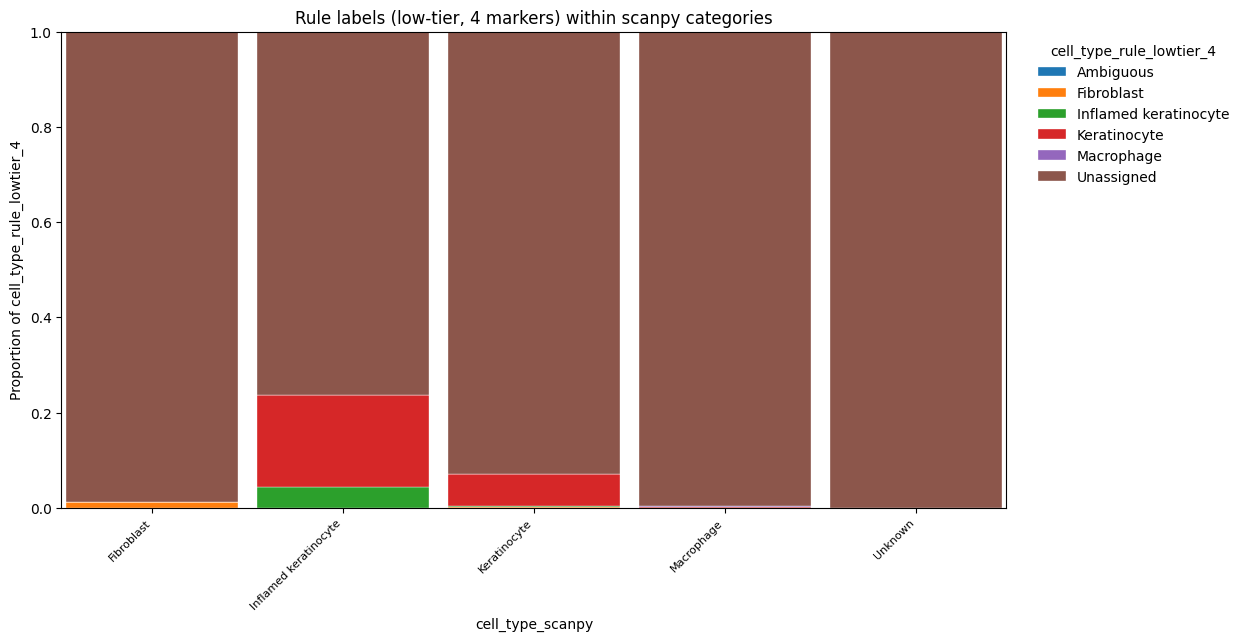

In [20]:
def _get_gene_counts(adata, genes):
    x = adata[:, genes].X
    if hasattr(x, "toarray"):
        return x.toarray()
    return np.asarray(x)


def assign_rule_labels(adata, genes_kera, genes_fibro, genes_macro, genes_infl_kera):
    """Assign labels when all genes in a panel have count > 0.
    Inflamed Keratinocyte takes priority over plain Keratinocyte when both
    fire. Cells matching more than one *other* population are 'Ambiguous';
    cells matching none are 'Unassigned'.
    """
    kera_pos = (_get_gene_counts(adata, genes_kera) > 0).all(axis=1)
    fibro_pos = (_get_gene_counts(adata, genes_fibro) > 0).all(axis=1)
    macro_pos = (_get_gene_counts(adata, genes_macro) > 0).all(axis=1)
    infl_kera_pos = (_get_gene_counts(adata, genes_infl_kera) > 0).all(axis=1)

    kera_lineage_pos = kera_pos | infl_kera_pos
    pos_matrix = np.column_stack([kera_lineage_pos, fibro_pos, macro_pos])
    n_pos = pos_matrix.sum(axis=1)

    labels = np.full(adata.n_obs, "Unassigned", dtype=object)
    labels[(n_pos == 1) & kera_lineage_pos & infl_kera_pos] = "Inflamed keratinocyte"
    labels[(n_pos == 1) & kera_lineage_pos & ~infl_kera_pos] = "Keratinocyte"
    labels[(n_pos == 1) & fibro_pos] = "Fibroblast"
    labels[(n_pos == 1) & macro_pos] = "Macrophage"
    labels[n_pos > 1] = "Ambiguous"
    return labels


# Build high-tier and low-tier marker sets at n = 2, 3, 4 genes each,
# from the detection_rates already computed.
tiers = {}
for tier_name, picker in [
    ("high", lambda r, n: r.head(n)),
    ("low", lambda r, n: r.tail(n)),
]:
    tiers[tier_name] = {}
    for n_genes in [2, 3, 4]:
        tiers[tier_name][n_genes] = {
            label: picker(rates, n_genes).index.tolist()
            for label, rates in detection_rates.items()
        }
        print(f"\n{tier_name.upper()}-tier, top {n_genes} markers:")
        for label in candidate_sets:
            print(f"  {label}: {tiers[tier_name][n_genes][label]}")


for tier_name in ["high", "low"]:
    for n_genes in [2, 3, 4]:
        print(f"\n{'='*60}")
        print(f"ROUND: {tier_name.upper()}-tier, {n_genes} markers each")
        print(f"{'='*60}")

        kera_markers = tiers[tier_name][n_genes]["KERA"]
        fibro_markers = tiers[tier_name][n_genes]["FIBRO"]
        macro_markers = tiers[tier_name][n_genes]["MACRO"]
        infl_kera_markers = tiers[tier_name][n_genes]["INFL_KERA"]
        col_name = f"cell_type_rule_{tier_name}tier_{n_genes}"

        adata_core.obs[col_name] = pd.Categorical(
            assign_rule_labels(
                adata_core, kera_markers, fibro_markers, macro_markers, infl_kera_markers
            )
        )
        print(f"Rule-based labels ({tier_name}-tier, {n_genes} markers):")
        display(adata_core.obs[col_name].value_counts())

        sc.pl.umap(
            adata_core,
            color=col_name,
            title=f"Rule-based ({tier_name}-tier, {n_genes} markers)",
        )

        SpatialCoord_plot(
            adata_core,
            variable=col_name,
            x_col="CenterX_global_px",
            y_col="CenterY_global_px",
            size=4,
            alpha=0.7,
            title=f"Spatial — rule-based ({tier_name}-tier, {n_genes} markers)",
        )

        all_markers = kera_markers + fibro_markers + macro_markers + infl_kera_markers
        sc.pl.dotplot(
            adata_core,
            var_names=all_markers,
            groupby=col_name,
            standard_scale="var",
            title=f"Selected markers by rule label ({tier_name}-tier, {n_genes} markers)",
        )

        print(f"\nComparison for sample ({tier_name}-tier, {n_genes} markers):\n")
        print("=== Counts ===")
        summary = pd.DataFrame({
            "cell_type_scanpy": adata_core.obs["cell_type_scanpy"].value_counts(),
            col_name: adata_core.obs[col_name].value_counts(),
        })
        display(summary)

        print("\n=== Crosstab (scanpy rows × rule cols) ===")
        ct = pd.crosstab(
            adata_core.obs["cell_type_scanpy"],
            adata_core.obs[col_name],
            margins=True,
        )
        display(ct)

        print("\n=== Row-normalized crosstab ===")
        ct_norm = pd.crosstab(
            adata_core.obs["cell_type_scanpy"],
            adata_core.obs[col_name],
            normalize="index",
        ).round(3)
        display(ct_norm)

        custom_barplot(
            adata_core,
            var_1=col_name,
            var_2="cell_type_scanpy",
            plot_type="bar",
            cluster_bars=False,
            title=f"Rule labels ({tier_name}-tier, {n_genes} markers) within scanpy categories",
        )

# cell composition across annotation methods

,cell_type_scanpy,cell_type_rule_hightier_2,cell_type_rule_hightier_3,cell_type_rule_hightier_4,cell_type_rule_lowtier_2,cell_type_rule_lowtier_3,cell_type_rule_lowtier_4
Ambiguous,0,296,87,17,18,3,1
Fibroblast,1698,872,533,480,117,54,22
Inflamed keratinocyte,135,1521,1482,1280,77,25,11
Keratinocyte,1897,94,135,192,248,191,154
Macrophage,549,39,10,6,15,4,1
Unassigned,0,2059,2634,2906,4406,4604,4692
Unknown,602,0,0,0,0,0,0


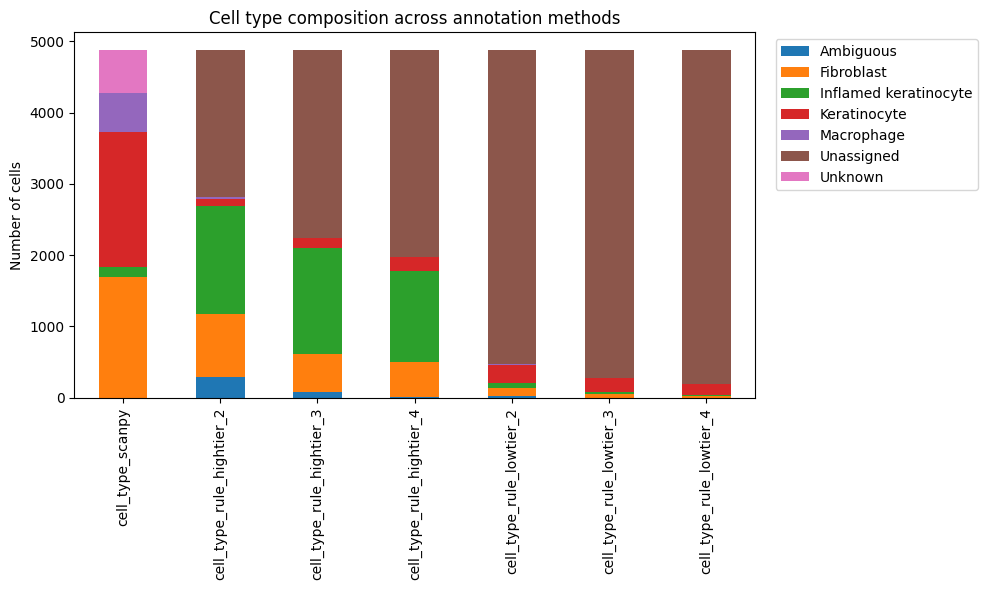

In [22]:
method_cols = [c for c in adata_core.obs.columns if c.startswith("cell_type_rule_")]

count_summary = pd.DataFrame({
    "cell_type_scanpy": adata_core.obs["cell_type_scanpy"].value_counts(),
    **{col: adata_core.obs[col].value_counts() for col in method_cols}
}).fillna(0).astype(int)

display(count_summary)

plot_df = count_summary.T  # methods as rows, cell types as columns
plot_df.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.ylabel("Number of cells")
plt.title("Cell type composition across annotation methods")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

method,cell_type_rule_hightier_2,cell_type_rule_hightier_3,cell_type_rule_hightier_4,cell_type_rule_lowtier_2,cell_type_rule_lowtier_3,cell_type_rule_lowtier_4
cell_type,,,,,,
Fibroblast,0.380,0.246,0.227,0.049,0.025,0.012
Inflamed keratinocyte,0.770,0.815,0.770,0.052,0.052,0.044
Keratinocyte,0.033,0.061,0.100,0.104,0.082,0.066
Macrophage,0.046,0.015,0.009,0.005,0.002,0.002


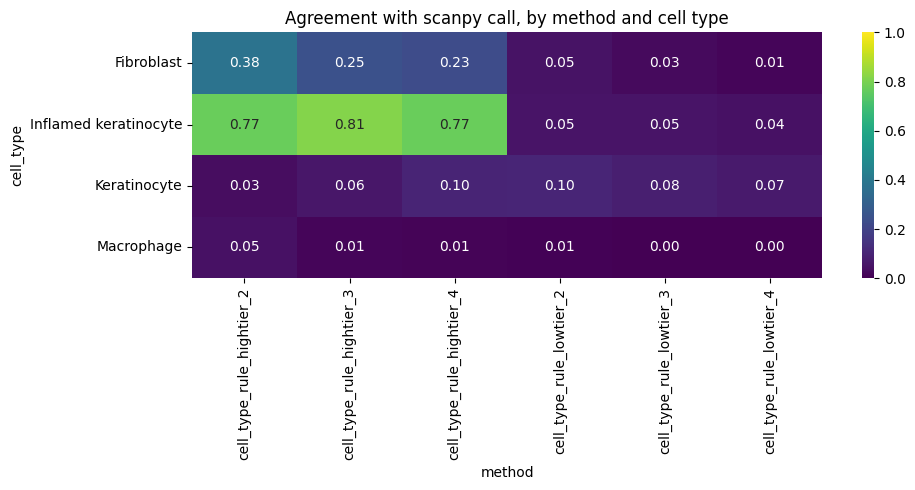

In [24]:
agreement_rows = []
for col in method_cols:
    ct_norm = pd.crosstab(
        adata_core.obs["cell_type_scanpy"],
        adata_core.obs[col],
        normalize="index",
    )
    for scanpy_label in ct_norm.index:
        if scanpy_label in ct_norm.columns:
            agreement_rows.append({
                "method": col,
                "cell_type": scanpy_label,
                "agreement": ct_norm.loc[scanpy_label, scanpy_label],
            })

agreement_df = pd.DataFrame(agreement_rows)
agreement_pivot = agreement_df.pivot(index="cell_type", columns="method", values="agreement")
display(agreement_pivot.round(3))

import seaborn as sns
plt.figure(figsize=(10, 5))
sns.heatmap(agreement_pivot, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
plt.title("Agreement with scanpy call, by method and cell type")
plt.tight_layout()
plt.show()

,unassigned_pct,ambiguous_pct,confident_pct
cell_type_rule_hightier_2,42.2,6.1,51.8
cell_type_rule_hightier_3,54.0,1.8,44.3
cell_type_rule_hightier_4,59.5,0.3,40.1
cell_type_rule_lowtier_2,90.3,0.4,9.4
cell_type_rule_lowtier_3,94.3,0.1,5.6
cell_type_rule_lowtier_4,96.1,0.0,3.9


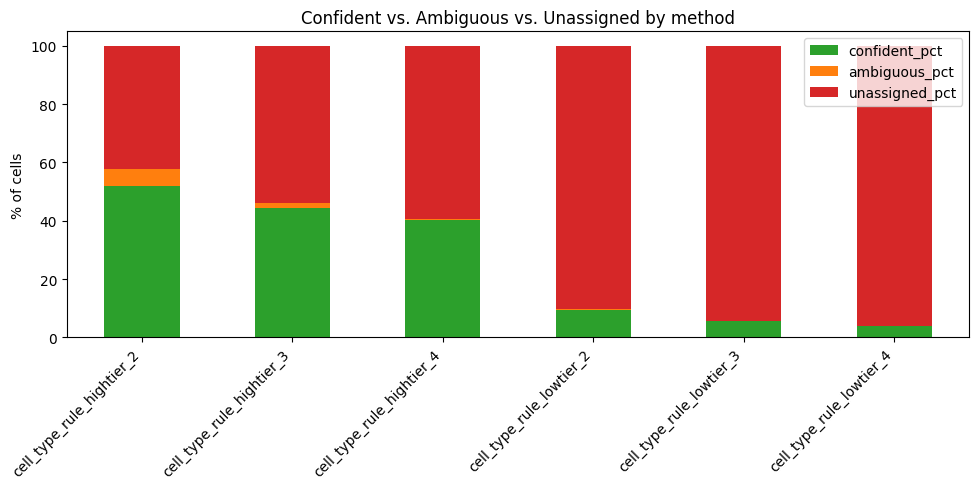

In [25]:
coverage = {}
for col in method_cols:
    vc = adata_core.obs[col].value_counts(normalize=True)
    coverage[col] = {
        "unassigned_pct": vc.get("Unassigned", 0) * 100,
        "ambiguous_pct": vc.get("Ambiguous", 0) * 100,
        "confident_pct": 100 - vc.get("Unassigned", 0) * 100 - vc.get("Ambiguous", 0) * 100,
    }
coverage_df = pd.DataFrame(coverage).T
display(coverage_df.round(1))

coverage_df[["confident_pct", "ambiguous_pct", "unassigned_pct"]].plot(
    kind="bar", stacked=True, figsize=(10, 5), color=["#2ca02c", "#ff7f0e", "#d62728"]
)
plt.ylabel("% of cells")
plt.title("Confident vs. Ambiguous vs. Unassigned by method")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

method,cell_type_rule_hightier_2,cell_type_rule_hightier_3,cell_type_rule_hightier_4,cell_type_rule_lowtier_2,cell_type_rule_lowtier_3,cell_type_rule_lowtier_4
cell_type,,,,,,
Fibroblast,0.259,0.216,0.198,0.282,0.204,0.045
Inflamed keratinocyte,0.932,0.926,0.919,0.909,0.720,0.455
Keratinocyte,0.330,0.141,0.016,0.206,0.183,0.182
Macrophage,0.359,0.200,0.167,0.800,0.750,0.000


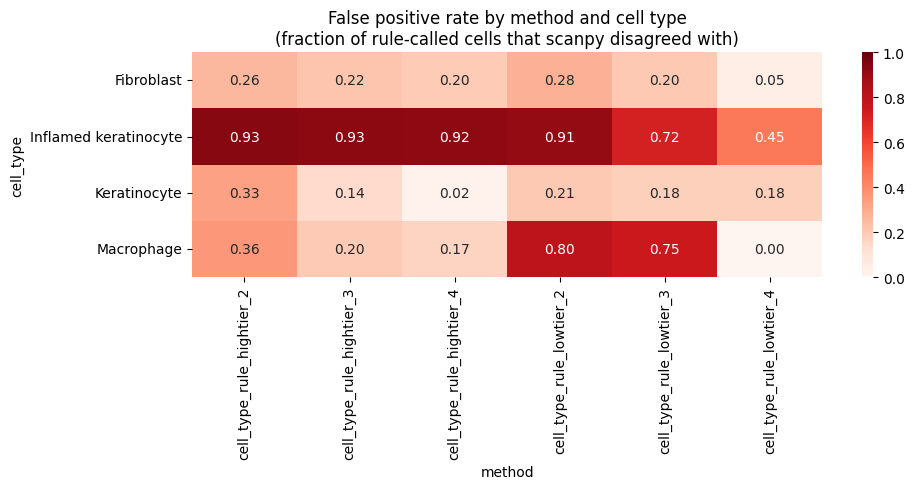

In [26]:
method_cols = [c for c in adata_core.obs.columns if c.startswith("cell_type_rule_")]

fp_rows = []
for col in method_cols:
    ct = pd.crosstab(adata_core.obs[col], adata_core.obs["cell_type_scanpy"])
    for rule_label in ct.index:
        if rule_label in ("Unassigned", "Ambiguous"):
            continue  # not a positive call, skip
        total_called = ct.loc[rule_label].sum()
        if rule_label in ct.columns:
            true_positives = ct.loc[rule_label, rule_label]
        else:
            true_positives = 0
        false_positives = total_called - true_positives
        fp_rate = false_positives / total_called if total_called > 0 else np.nan
        fp_rows.append({
            "method": col,
            "cell_type": rule_label,
            "n_called": total_called,
            "n_false_positive": false_positives,
            "fp_rate": fp_rate,
        })

fp_df = pd.DataFrame(fp_rows)
fp_pivot = fp_df.pivot(index="cell_type", columns="method", values="fp_rate")
display(fp_pivot.round(3))

# heatmap version
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.heatmap(fp_pivot, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1)
plt.title("False positive rate by method and cell type\n(fraction of rule-called cells that scanpy disagreed with)")
plt.tight_layout()
plt.show()

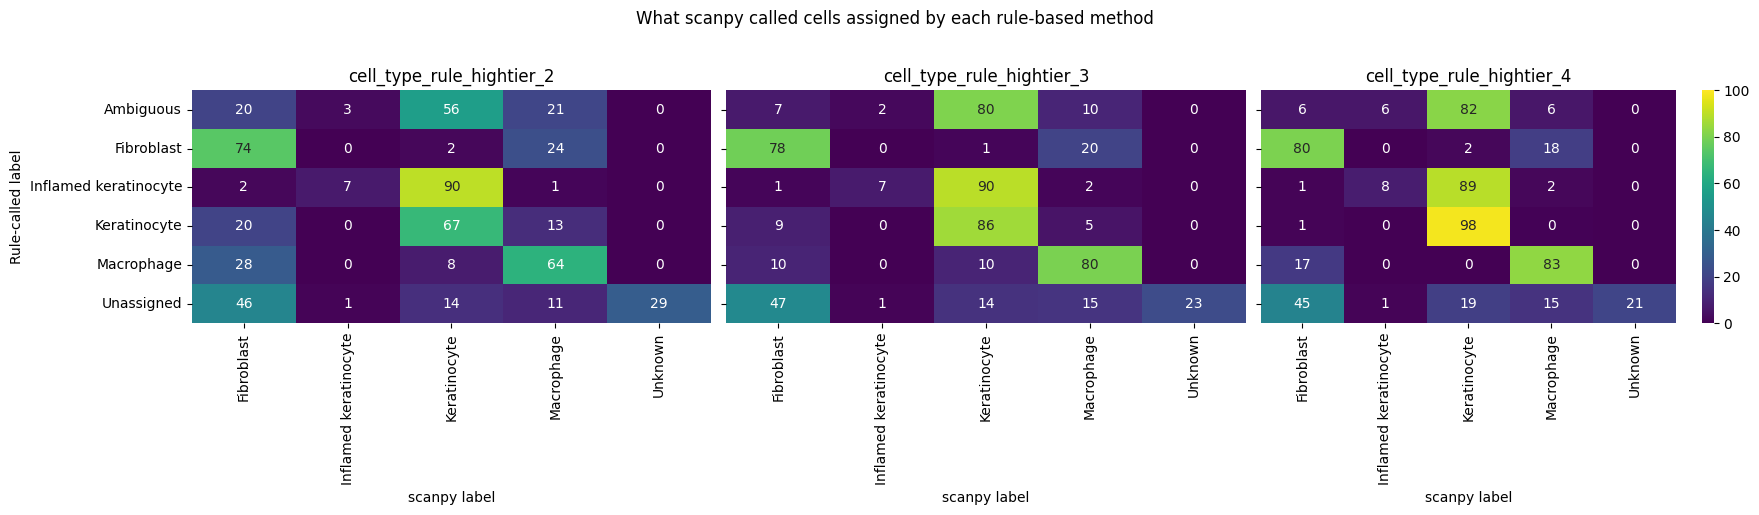

In [27]:
import seaborn as sns

methods_to_plot = [
    "cell_type_rule_hightier_2",
    "cell_type_rule_hightier_3",
    "cell_type_rule_hightier_4",
]

fig, axes = plt.subplots(1, len(methods_to_plot), figsize=(6 * len(methods_to_plot), 5), sharey=True)

for ax, method in zip(axes, methods_to_plot):
    breakdown_pct = pd.crosstab(
        adata_core.obs[method], adata_core.obs["cell_type_scanpy"], normalize="index"
    ).round(3) * 100

    sns.heatmap(
        breakdown_pct,
        annot=True,
        fmt=".0f",
        cmap="viridis",
        vmin=0,
        vmax=100,
        ax=ax,
        cbar=(ax == axes[-1]),  # only show colorbar once, on the last panel
    )
    ax.set_title(method)
    ax.set_xlabel("scanpy label")
    ax.set_ylabel("Rule-called label" if ax == axes[0] else "")

plt.suptitle("What scanpy called cells assigned by each rule-based method", y=1.02)
plt.tight_layout()
plt.show()